In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torchinfo
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch.nn.functional as F

from torchlake.common.controller.recorder import TrainRecorder
from torchlake.common.controller.weight_manager import WeightManager
from torchlake.common.datasets.images import ImageDataset
from torchlake.common.models import VGGFeatureExtractor
from torchlake.common.utils.convert import img_tensor_to_np
from torchlake.common.utils.image import save_img_array
from torchlake.common.utils.plot import plot_grids
from torchlake.style_transfer.controller.trainer_texture import TextureTrainer
from torchlake.style_transfer.models.neural_style_transfer import \
    NeuralStyleTransferLoss
from torchlake.style_transfer.models.texture import TextureNet

# setting

In [2]:
artifacts_path = Path('../../artifacts/texture-net')
artifacts_path.mkdir(exist_ok=True)

data_path = Path('../../data/VOCdevkit/**/JPEGImages/*.jpg')
content_path = Path("../../data/contents")
style_path = Path("../../data/styles")

In [3]:
DEVICE = torch.device('cuda:0')

In [4]:
CONTENT_LAYER_NAME = '2_1'
STYLE_LAYER_NAMES = ['1_1', '2_1', '3_1', '4_1', '5_1']

In [5]:
NUM_SCALE_FACTOR = 5

# data

In [ ]:
BATCH_SIZE = 16
IMAGE_SIZE = 224

In [7]:
transform = v2.Compose([
  v2.Resize((IMAGE_SIZE, IMAGE_SIZE)),
  v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True),
])

In [8]:
dataset = ImageDataset(data_path.as_posix(), transform)

In [9]:
def collate_fn(batch):
    stacks = []
    
    batch = torch.stack(batch)
    for i in range(NUM_SCALE_FACTOR):
        dp = F.interpolate(batch, scale_factor=2**-i)
        z = torch.rand(dp.size(0), 1, dp.size(2), dp.size(3))
        dp = torch.cat((dp, z), 1)
        stacks.append(dp)
            
    return stacks 

In [10]:
data_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    pin_memory=True,
    collate_fn=collate_fn,
)

In [11]:
for batch in data_loader:
    for datapoint in batch:
        print(datapoint.shape)
    break

torch.Size([24, 4, 224, 224])
torch.Size([24, 4, 112, 112])
torch.Size([24, 4, 56, 56])
torch.Size([24, 4, 28, 28])
torch.Size([24, 4, 14, 14])


In [12]:
style = Image.open(style_path.joinpath('starry.jpg'))
style = transform(style).unsqueeze(0).to(DEVICE)

# model

In [13]:
feature_extractor = VGGFeatureExtractor("vgg19", "relu", trainable=False).to(DEVICE)

In [14]:
model = TextureNet(4, 3, num_scale_factor=NUM_SCALE_FACTOR).to(DEVICE)

In [15]:
torchinfo.summary(model)

Layer (type:depth-idx)                        Param #
TextureNet                                    --
├─ModuleList: 1-1                             --
│    └─Sequential: 2-1                        --
│    │    └─ConvINReLU: 3-1                   304
│    │    └─ConvINReLU: 3-2                   592
│    │    └─ConvINReLU: 3-3                   80
│    └─Sequential: 2-2                        --
│    │    └─ConvINReLU: 3-4                   304
│    │    └─ConvINReLU: 3-5                   592
│    │    └─ConvINReLU: 3-6                   80
│    └─Sequential: 2-3                        --
│    │    └─ConvINReLU: 3-7                   304
│    │    └─ConvINReLU: 3-8                   592
│    │    └─ConvINReLU: 3-9                   80
│    └─Sequential: 2-4                        --
│    │    └─ConvINReLU: 3-10                  304
│    │    └─ConvINReLU: 3-11                  592
│    │    └─ConvINReLU: 3-12                  80
│    └─Sequential: 2-5                        --
│    │ 

# style transfer

## train

In [16]:
EPOCH = 3

In [17]:
CONTENT_WEIGHT = 1e0
STYLE_WEIGHT = 1e4

In [18]:
recorder = TrainRecorder(total_epoch=EPOCH, num_loss=3, loss_names=["total", "content", "style"])
recorder.increment_data_size(len(dataset))

In [19]:
trainer = TextureTrainer(EPOCH, DEVICE)

In [20]:
criterion = NeuralStyleTransferLoss(
    feature_extractor,
    content_layer_name=CONTENT_LAYER_NAME,
    style_layer_names=STYLE_LAYER_NAMES,
    content_weight=CONTENT_WEIGHT,
    style_weight=STYLE_WEIGHT,
    norm_generated=False,
    return_all_loss=True,
)

In [21]:
criterion.set_style_features(style.repeat(BATCH_SIZE, 1, 1, 1))

In [22]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [23]:
training_losses = trainer.run(data_loader, model, optimizer, criterion, recorder=recorder)

Enable AMP: False
Training...


100%|██████████| 1128/1128 [07:33<00:00,  2.49it/s]


------------------------------------
Epoch 1
------------------------------------
total: 1.5069e-01 (0.00%)
content: 9.4109e-02 (0.00%)
style: 5.6586e-06 (0.00%)


100%|██████████| 1128/1128 [09:59<00:00,  1.88it/s]


------------------------------------
Epoch 2
------------------------------------
total: 1.0620e-01 (-30.00%)
content: 5.8997e-02 (-37.00%)
style: 4.7200e-06 (-17.00%)


100%|██████████| 1128/1128 [11:12<00:00,  1.68it/s]

------------------------------------
Epoch 3
------------------------------------
total: 9.6321e-02 (-9.00%)
content: 5.0452e-02 (-14.00%)
style: 4.5869e-06 (-3.00%)


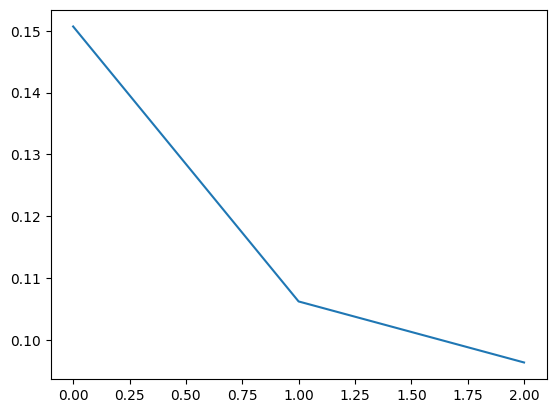

In [24]:
plt.plot(training_losses)

In [25]:
wm = WeightManager(artifacts_path.joinpath("starry.transfer.pth").as_posix())

In [26]:
wm.save_weight(model.state_dict(), wm.get_filename())

Save weight to ..\..\artifacts\texture-net\starry.transfer.pth, model size is 0.33MiB


## visualize

In [27]:
test_transform = v2.Compose([
  v2.Resize((512, 512)),
  v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True),
])

In [42]:
content = Image.open(content_path.joinpath('101.jpg'))
content = test_transform(content).unsqueeze(0).to(DEVICE)

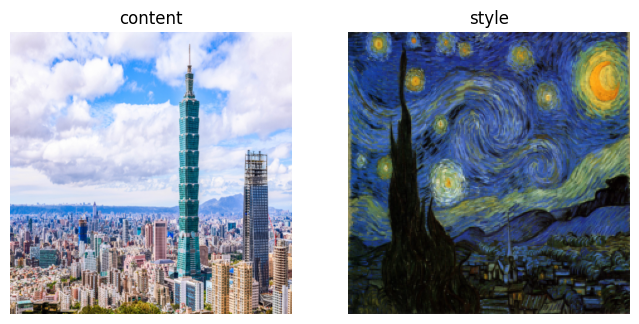

In [43]:
plot_grids(
    [img_tensor_to_np(content), img_tensor_to_np(style)],
    ["content", "style"],
    1,
    2,
)

In [44]:
stacks = []
for i in range(NUM_SCALE_FACTOR):
    dp = F.interpolate(content, scale_factor=2**-i)
    z = torch.rand(dp.size(0), 1, dp.size(2), dp.size(3)).to(DEVICE)
    dp = torch.cat((dp, z), 1)
    stacks.append(dp)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.760039..4.3526945].


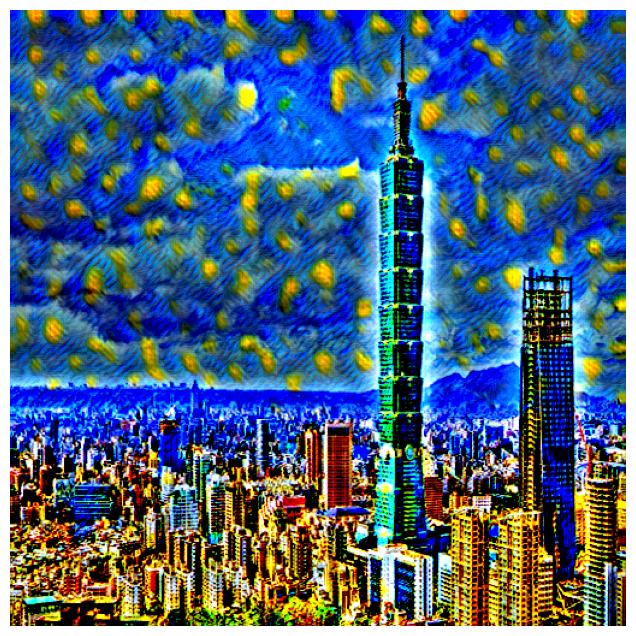

In [45]:
# z, _ = next(data_generator(style, model, DEVICE))
output = model(stacks)
plot_grids([img_tensor_to_np(output)])

In [32]:
output_path = artifacts_path.joinpath('output.png')

In [33]:
save_img_array(img_tensor_to_np(output)[:, :, ::-1], output_path.as_posix())

# texture synthesis

## train

In [16]:
def data_generator(style: torch.Tensor, num_scale_factor: int, device: torch.device):
    _, c, h, w = style.shape

    noise = torch.rand((BATCH_SIZE, c, h, w), device=device)
    noises = []
    for _ in range(num_scale_factor):
        noises.append(noise)
        noise = F.interpolate(noise, scale_factor=1/2)
    
    yield noises

In [17]:
EPOCH = 5

In [18]:
CONTENT_WEIGHT = 1e0
STYLE_WEIGHT = 1

In [19]:
recorder = TrainRecorder(total_epoch=EPOCH, num_loss=2, loss_names=["total", "style"])
recorder.increment_data_size(len(dataset))

In [20]:
trainer = TextureTrainer(EPOCH, DEVICE)

In [21]:
criterion = NeuralStyleTransferLoss(
    feature_extractor,
    content_layer_name=CONTENT_LAYER_NAME,
    style_layer_names=STYLE_LAYER_NAMES,
    content_weight=CONTENT_WEIGHT,
    style_weight=STYLE_WEIGHT,
    norm_generated=False,
    return_all_loss=True,
)

In [22]:
criterion.set_style_features(style.repeat(BATCH_SIZE, 1, 1, 1))

In [23]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [24]:
for t in next(data_generator(style, NUM_SCALE_FACTOR, DEVICE)):
    print(t.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 112, 112])
torch.Size([16, 3, 56, 56])
torch.Size([16, 3, 28, 28])
torch.Size([16, 3, 14, 14])


In [25]:
training_losses = trainer.run(
    data_generator(style, NUM_SCALE_FACTOR, DEVICE),
    model,
    optimizer,
    criterion,
    recorder=recorder,
)

Enable AMP: False
Training...


1it [00:00,  1.78it/s]


------------------------------------
Epoch 1
------------------------------------
total: 6.0126e-04 (0.00%)
style: 6.0121e-04 (0.00%)


0it [00:00, ?it/s]


------------------------------------
Epoch 2
------------------------------------
total: 0.0000e+00 (-100.00%)
style: 0.0000e+00 (-100.00%)


...

------------------------------------
Epoch 3
------------------------------------
total: 0.0000e+00 (0.00%)
style: 0.0000e+00 (0.00%)


0it [00:00, ?it/s]


------------------------------------
Epoch 4
------------------------------------
total: 0.0000e+00 (0.00%)
style: 0.0000e+00 (0.00%)


0it [00:00, ?it/s]

------------------------------------
Epoch 5
------------------------------------
total: 0.0000e+00 (0.00%)
style: 0.0000e+00 (0.00%)


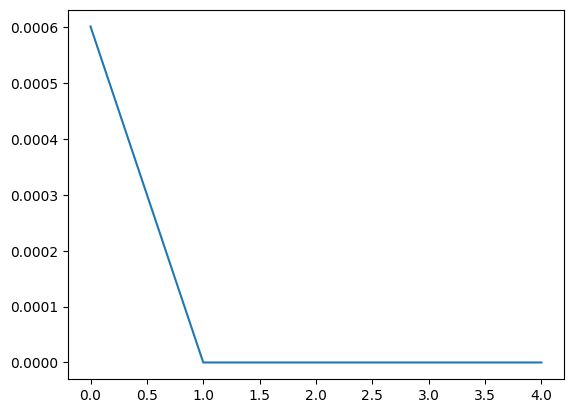

In [26]:
plt.plot(training_losses)

In [27]:
wm = WeightManager(artifacts_path.joinpath("starry.synthesis.pth").as_posix())

In [28]:
wm.save_weight(model.state_dict(), wm.get_filename())

Save weight to ..\..\artifacts\texture-net\starry.synthesis.pth, model size is 0.33MiB


## visualize

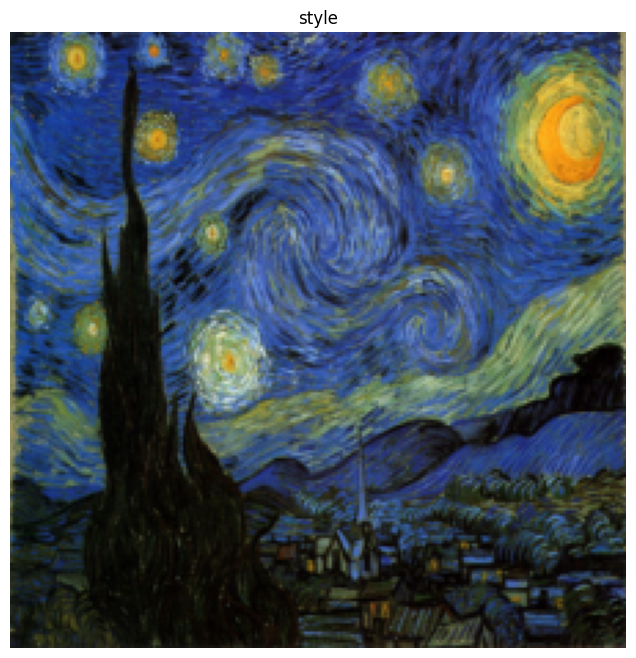

In [29]:
plot_grids(
    [img_tensor_to_np(style)],
    ["style"],
    1,
    1,
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1898273..6.119985].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1977341..5.676369].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4444095..6.7398148].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3674917..6.353973].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3953376..5.6460547].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.916338..6.2228556].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4172515..7

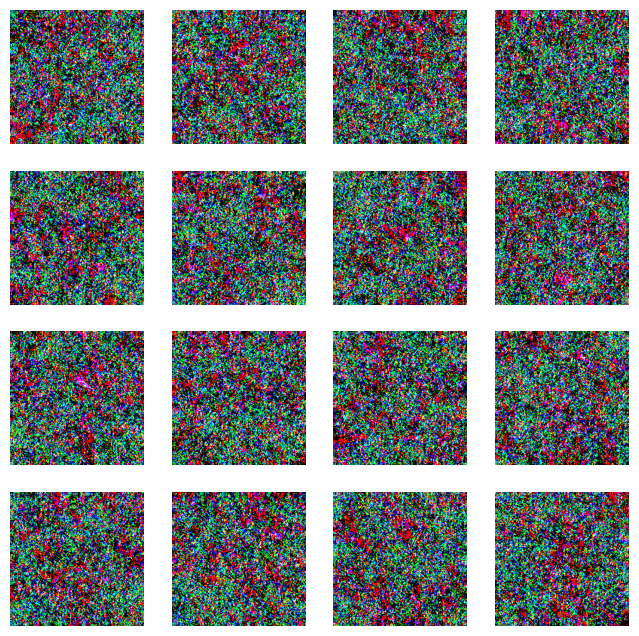

In [30]:
stacks = next(data_generator(style, NUM_SCALE_FACTOR, DEVICE))
output = model(stacks)
plot_grids(img_tensor_to_np(output), num_col=4, num_row=4)